In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

import shap

# Load processed data
X_train = np.load('C:\\Users\\91906\\OneDrive\\Desktop\\churn-prediction\\data\\X_train.npy')

X_test = np.load('C:\\Users\\91906\\OneDrive\\Desktop\\churn-prediction\\data\\X_test.npy')

y_train = np.load('C:\\Users\\91906\\OneDrive\\Desktop\\churn-prediction\\data\\y_train.npy')

y_test = np.load('C:\\Users\\91906\\OneDrive\\Desktop\\churn-prediction\\data\\y_test.npy')

# Load feature names
feature_names = pickle.load(
    open('C:\\Users\\91906\\OneDrive\\Desktop\\churn-prediction\\models\\feature_names.pkl', 'rb')
)

print(X_train.shape)

print(X_test.shape)

(8278, 36)
(1409, 36)


In [2]:
models = {

    'Logistic Regression':
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Random Forest':
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'XGBoost':
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}

results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    # ROC-AUC
    auc = roc_auc_score(y_test, y_prob)

    # Save results
    results[name] = {
        'model': model,
        'auc': auc,
        'pred': y_pred,
        'prob': y_prob
    }

    print(f"\n{'='*50}")

    print(f"{name}")

    print(f"ROC-AUC: {auc:.4f}")

    print(classification_report(
        y_test,
        y_pred,
        target_names=['No Churn', 'Churn']
    ))


Logistic Regression
ROC-AUC: 0.8373
              precision    recall  f1-score   support

    No Churn       0.86      0.86      0.86      1035
       Churn       0.60      0.61      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409


Random Forest
ROC-AUC: 0.8168
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1035
       Churn       0.55      0.58      0.57       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.76      0.77      1409



c:\Users\91906\OneDrive\Desktop\churn-prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:35:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
ROC-AUC: 0.8149
              precision    recall  f1-score   support

    No Churn       0.85      0.83      0.84      1035
       Churn       0.56      0.58      0.57       374

    accuracy                           0.77      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.77      0.77      1409



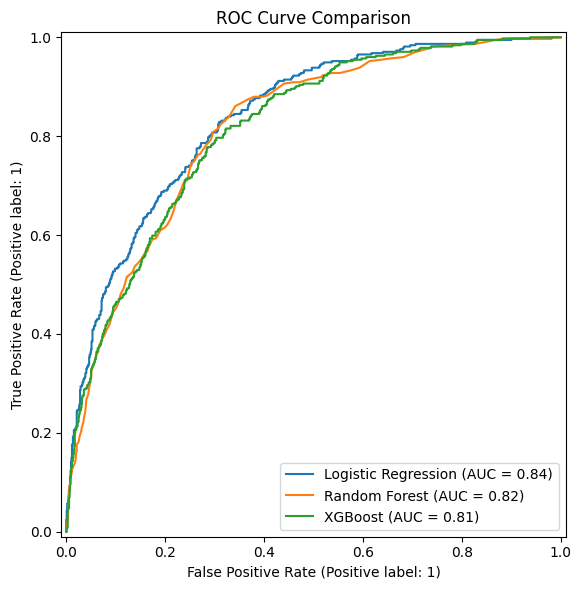

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, r in results.items():

    RocCurveDisplay.from_predictions(
        y_test,
        r['prob'],
        name=name,
        ax=ax
    )

ax.set_title('ROC Curve Comparison')

plt.tight_layout()

plt.show()

In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [3, 5, 7],

    'learning_rate': [0.05, 0.1, 0.2],

    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

gs = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train, y_train)

print("Best Parameters:")
print(gs.best_params_)

print("\nBest CV ROC-AUC:")
print(gs.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

Best CV ROC-AUC:
0.93235782417563


In [5]:
# Best tuned model
best_model = gs.best_estimator_

# Predict probabilities
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Predict classes
y_pred_best = best_model.predict(X_test)

# Final ROC-AUC
best_auc = roc_auc_score(y_test, y_prob_best)

print(f"Tuned XGBoost Test ROC-AUC: {best_auc:.4f}")

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_best,
    target_names=['No Churn', 'Churn']
))

Tuned XGBoost Test ROC-AUC: 0.8218

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.58      0.58      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



 99%|===================| 1391/1409 [00:29<00:00]        

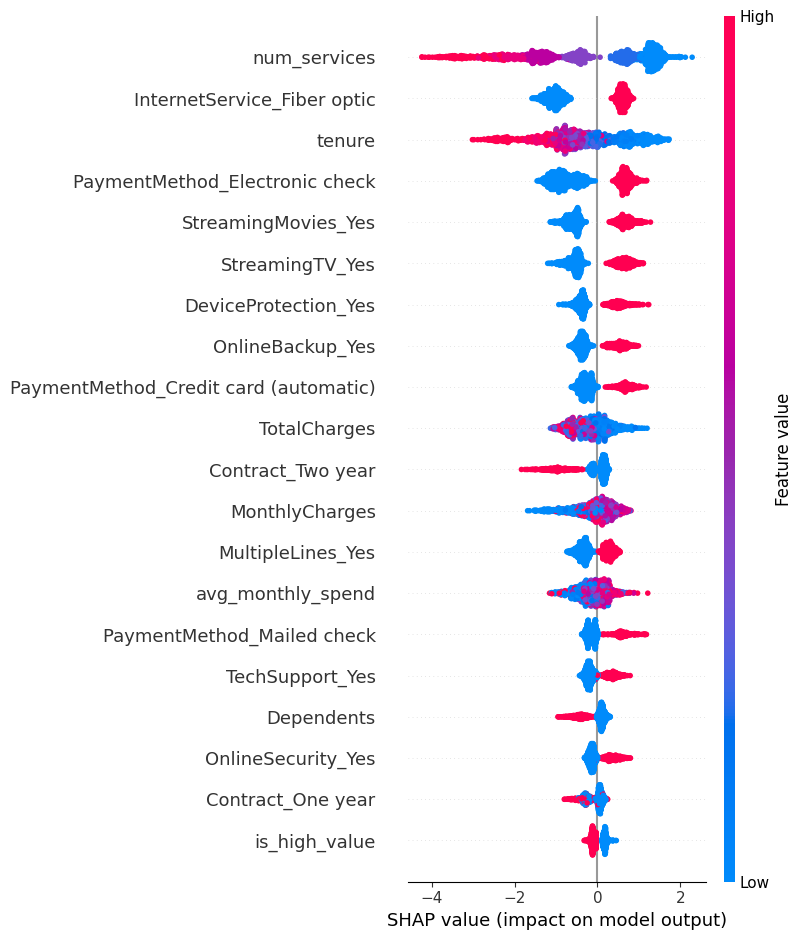

In [6]:
# Create SHAP explainer
explainer = shap.Explainer(
    best_model,
    X_train
)

# Calculate SHAP values
shap_values = explainer(X_test)

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names
)

In [7]:
# Save tuned XGBoost model
pickle.dump(
    best_model,
    open('../models/xgb_model.pkl', 'wb')
)

print("Best model saved successfully!")

Best model saved successfully!


In [8]:
# Create dataframe from test data
X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

# Add prediction probabilities
X_test_df['churn_probability'] = y_prob_best

# Add actual labels
X_test_df['actual_churn'] = y_test

# High-risk customers
high_risk = X_test_df[
    X_test_df['churn_probability'] > 0.7
]

print(f"High-risk customers: {len(high_risk)}")

print("\nTop High-Risk Customers:\n")

print(
    high_risk[
        ['churn_probability']
    ].head()
)

High-risk customers: 231

Top High-Risk Customers:

    churn_probability
1            0.985754
5            0.816988
13           0.963427
20           0.783057
26           0.732007


In [9]:
# Export predictions for dashboard
X_test_df.to_csv(
    '../data/predictions.csv',
    index=False
)

print("predictions.csv saved successfully!")

predictions.csv saved successfully!


In [4]:
import pandas as pd

# Reload original dataframe
original_df = pd.read_csv('data/telco_churn.csv')

# Fix TotalCharges
original_df['TotalCharges'] = pd.to_numeric(
    original_df['TotalCharges'],
    errors='coerce'
)

original_df['TotalCharges'] = original_df['TotalCharges'].fillna(
    original_df['TotalCharges'].median()
)

# Select test rows
original_test = original_df.iloc[y_test.index]

# Reset index
original_test = original_test.reset_index(drop=True)

# Add predictions
original_test['churn_probability'] = y_prob_best

original_test['actual_churn'] = y_test.values

# Save dashboard dataset
original_test.to_csv(
    'data/predictions_dashboard.csv',
    index=False
)

print("Dashboard dataset saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'data/telco_churn.csv'